In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, average_precision_score,
                             ConfusionMatrixDisplay)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [89]:
df = pd.read_csv('data/cleaned_data.csv')
df.rename(columns={'Attrition': 'target'}, inplace=True)
df

,Age,target,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [90]:
# 

cols_to_drop = ['DailyRate', 'HourlyRate', 'MonthlyRate']
df = df.drop(cols_to_drop, axis=1)
df.shape

(1470, 28)

In [ ]:
# Добавим новые признаки

# Молодой сотрудник
df['IsYoung'] = (df['Age'] < 30).astype(int)

# Высокий риск: сверхурочная работа + низкая удовлетворенность
df['HighRisk'] = ((df['OverTime'] == 'Yes') & (df['JobSatisfaction'] <= 2)).astype(int)

# Сколько сменил компаний относительно стажа
df['JobHopping'] = (df['NumCompaniesWorked'] / (df['TotalWorkingYears'] + 1)).round().astype(int)

# Низкий баланс работы и жизни
df['BadWorkLife'] = (df['WorkLifeBalance'] == 1).astype(int)

# Большая дистанция от дома
df['FarFromHome'] = (df['DistanceFromHome'] > 10).astype(int)


In [92]:
# Преобразуем целевую переменную
df['target'] = df['target'].map({'Yes': 1, 'No': 0})


In [ ]:
def show_datasets(X_train, X_test, Y_train, Y_test):
    
    # DataFrame для обучающей выборки
    train_df = pd.DataFrame(
        data=X_train,
        columns=X_train.columns  
    )
    train_df['y'] = Y_train    

    # DataFrame для тестовой выборки
    test_df = pd.DataFrame(
        data=X_test,
        columns=X_test.columns
    )
    test_df['y'] = Y_test    

    print(f"Train dataset\n Размер датасета {train_df.shape}")
    print(f"Доля увольнений в Train: {Y_train.mean():.2%}\n")
    display(train_df)
    
    print(f"Test dataset\n Размер датасета {test_df.shape}")
    print(f"Доля увольнений в Test: {Y_test.mean():.2%}\n")
    display(test_df)

In [94]:
# Разделим на X и y
X = df.drop('target', axis=1)
y = df['target']

# Стратифицированное разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [95]:
show_datasets(X_train, X_test, y_train, y_test)

Train dataset
 Размер датасета (1176, 33)
Доля увольнений в Train: 16.16%



,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IsYoung,HighRisk,JobHopping,BadWorkLife,FarFromHome,y
1194,47,Travel_Rarely,Sales,2,4,Life Sciences,2,Female,4,4,...,3,2,1,2,0,0,0,0,0,0
128,22,Travel_Rarely,Research & Development,2,1,Technical Degree,3,Male,3,1,...,2,1,2,1,1,0,0,0,0,0
810,46,Travel_Rarely,Sales,3,1,Marketing,1,Male,3,4,...,12,9,4,9,0,0,0,0,0,0
478,25,Travel_Rarely,Sales,13,1,Medical,2,Male,3,1,...,7,4,0,6,1,0,0,0,1,0
491,43,Travel_Frequently,Research & Development,9,5,Medical,4,Male,3,2,...,8,7,4,7,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,23,Travel_Rarely,Sales,7,3,Life Sciences,3,Male,3,1,...,3,2,0,2,1,0,0,0,0,1
963,38,Travel_Rarely,Sales,2,2,Life Sciences,2,Female,3,2,...,7,7,1,7,0,0,0,0,0,0
734,22,Travel_Rarely,Research & Development,8,1,Life Sciences,2,Male,1,1,...,4,3,1,1,1,0,0,0,0,0
1315,36,Travel_Rarely,Research & Development,2,4,Other,4,Female,3,2,...,1,0,0,0,0,1,0,0,0,0


Test dataset
 Размер датасета (294, 33)
Доля увольнений в Test: 15.99%



,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IsYoung,HighRisk,JobHopping,BadWorkLife,FarFromHome,y
1061,24,Non-Travel,Sales,13,2,Life Sciences,4,Female,3,1,...,1,0,0,0,1,0,0,0,1,0
891,44,Travel_Rarely,Research & Development,2,1,Life Sciences,1,Female,4,1,...,10,5,7,7,0,0,0,0,0,0
456,31,Travel_Rarely,Sales,7,3,Life Sciences,3,Male,2,3,...,5,4,0,1,0,0,1,0,0,0
922,44,Travel_Rarely,Research & Development,4,2,Life Sciences,3,Male,4,5,...,25,9,14,13,0,0,0,0,0,0
69,36,Travel_Rarely,Research & Development,9,3,Medical,4,Male,2,1,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,43,Travel_Rarely,Human Resources,2,3,Life Sciences,2,Male,3,1,...,9,7,1,8,0,0,0,0,0,0
1352,44,Travel_Rarely,Research & Development,1,4,Life Sciences,2,Male,4,2,...,2,0,2,2,0,0,0,0,0,0
1236,36,Travel_Rarely,Sales,13,5,Marketing,2,Male,2,2,...,2,2,2,2,0,1,0,0,1,1
1023,56,Travel_Rarely,Research & Development,1,2,Life Sciences,1,Female,3,1,...,3,2,1,0,0,0,0,0,0,0


In [96]:
CAT_COLS = X.select_dtypes(include=['str']).columns.tolist()
ORD_COLS = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 
            'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']
NUM_COLS = [col for col in X.select_dtypes(include=['int64', 'float64']).columns if col not in ORD_COLS]

(len(NUM_COLS) + len(CAT_COLS) + len(ORD_COLS))

32

In [97]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_COLS + ORD_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
    ],
    remainder='drop'
)

In [98]:
pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(
            max_depth=6,
            min_samples_split=10,
            class_weight='balanced',
            random_state=42
        ))
    ]),
    
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_split=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  
            random_state=42,
            eval_metric='logloss',
        ))
    ])
}

In [99]:
results = {}

print("\n" + "="*65)
print("ОБУЧЕНИЕ МОДЕЛЕЙ")
print("="*65)

for name, pipe in pipelines.items():
    print(f"\n→ {name}")
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'pipeline': pipe,
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f"  F1        : {results[name]['f1']:.4f}")
    print(f"  ROC-AUC   : {results[name]['roc_auc']:.4f}")
    print(f"  PR-AUC    : {results[name]['pr_auc']:.4f}")
    print(f"  Precision : {results[name]['precision']:.4f}")
    print(f"  Recall    : {results[name]['recall']:.4f}")

# Сводная таблица
results_df = pd.DataFrame({
    name: {
        'F1': res['f1'],
        'ROC-AUC': res['roc_auc'],
        'PR-AUC': res['pr_auc'],
        'Precision': res['precision'],
        'Recall': res['recall']
    } for name, res in results.items()
}).T.round(4).sort_values('F1', ascending=False)

print("\n" + "="*65)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*65)
print(results_df)


ОБУЧЕНИЕ МОДЕЛЕЙ

→ Logistic Regression
  F1        : 0.4923
  ROC-AUC   : 0.8150
  PR-AUC    : 0.5931
  Precision : 0.3855
  Recall    : 0.6809

→ Decision Tree
  F1        : 0.4333
  ROC-AUC   : 0.6518
  PR-AUC    : 0.3517
  Precision : 0.3562
  Recall    : 0.5532

→ Random Forest
  F1        : 0.4898
  ROC-AUC   : 0.7878
  PR-AUC    : 0.4455
  Precision : 0.4706
  Recall    : 0.5106

→ XGBoost
  F1        : 0.4359
  ROC-AUC   : 0.8100
  PR-AUC    : 0.5059
  Precision : 0.5484
  Recall    : 0.3617

СРАВНЕНИЕ МОДЕЛЕЙ
                         F1  ROC-AUC  PR-AUC  Precision  Recall
Logistic Regression  0.4923   0.8150  0.5931     0.3855  0.6809
Random Forest        0.4898   0.7878  0.4455     0.4706  0.5106
XGBoost              0.4359   0.8100  0.5059     0.5484  0.3617
Decision Tree        0.4333   0.6518  0.3517     0.3562  0.5532


In [100]:
best_name = results_df.index[0]
print(f"\nЛучшая модель: {best_name}")


Лучшая модель: Logistic Regression


In [101]:
param_grid = {
        'model__n_estimators': [100, 150, 250, 300],
        'model__max_depth': [3, 5, 8, 10],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2'],
    }

base_pipe = pipelines['Random Forest']

In [102]:
grid = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [103]:
grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_
print("\nЛучшие параметры случайного леса:", grid.best_params_)
print("Лучший f1 на кросс-валидации:", round(grid.best_score_, 4))

Fitting 3 folds for each of 288 candidates, totalling 864 fits

Лучшие параметры случайного леса: {'model__max_depth': 8, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Лучший f1 на кросс-валидации: 0.54


In [104]:
y_pred_final = best_pipeline.predict(X_test)
y_proba_final = best_pipeline.predict_proba(X_test)[:, 1]

print("\n" + "="*65)
print("ФИНАЛЬНЫЙ ОТЧЁТ")
print("="*65)
print(classification_report(y_test, y_pred_final, target_names=['Остался (0)', 'Ушёл (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_final):.4f}")


ФИНАЛЬНЫЙ ОТЧЁТ
              precision    recall  f1-score   support

 Остался (0)       0.91      0.89      0.90       247
    Ушёл (1)       0.50      0.55      0.53        47

    accuracy                           0.84       294
   macro avg       0.71      0.72      0.71       294
weighted avg       0.85      0.84      0.84       294

ROC-AUC: 0.8004


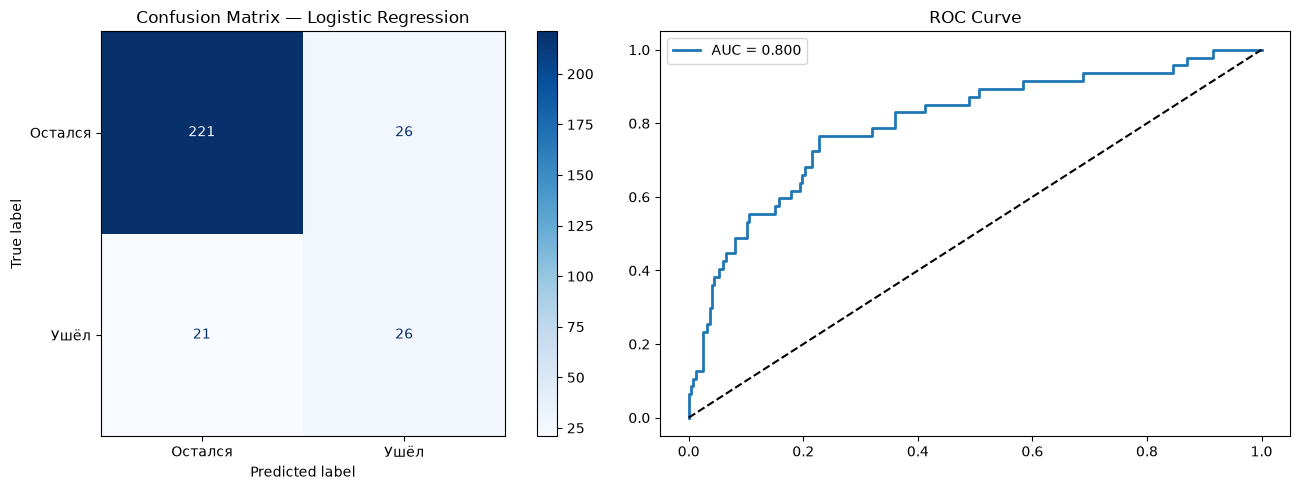

In [105]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Остался', 'Ушёл'],
    cmap='Blues', ax=ax[0]
)
ax[0].set_title(f'Confusion Matrix — {best_name}')

fpr, tpr, _ = roc_curve(y_test, y_proba_final)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba_final):.3f}', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('ROC Curve')
ax[1].legend()
plt.tight_layout()
plt.show()

In [106]:
# Получаем имена признаков после OneHotEncoder
all_feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
# all_feature_names = preprocessor.get_feature_names_out()

all_feature_names

array(['num__Age', 'num__DistanceFromHome', 'num__MonthlyIncome',
       'num__NumCompaniesWorked', 'num__PercentSalaryHike',
       'num__TotalWorkingYears', 'num__TrainingTimesLastYear',
       'num__YearsAtCompany', 'num__YearsInCurrentRole',
       'num__YearsSinceLastPromotion', 'num__YearsWithCurrManager',
       'num__IsYoung', 'num__HighRisk', 'num__JobHopping',
       'num__BadWorkLife', 'num__FarFromHome', 'num__Education',
       'num__EnvironmentSatisfaction', 'num__JobInvolvement',
       'num__JobLevel', 'num__JobSatisfaction', 'num__PerformanceRating',
       'num__RelationshipSatisfaction', 'num__StockOptionLevel',
       'num__WorkLifeBalance', 'cat__BusinessTravel_Non-Travel',
       'cat__BusinessTravel_Travel_Frequently',
       'cat__BusinessTravel_Travel_Rarely',
       'cat__Department_Human Resources',
       'cat__Department_Research & Development', 'cat__Department_Sales',
       'cat__EducationField_Human Resources',
       'cat__EducationField_Life Sciences'

C:\Users\gabri\AppData\Local\Temp\ipykernel_13948\3346203546.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(20).values, y=importances.head(20).index, palette='Set2')


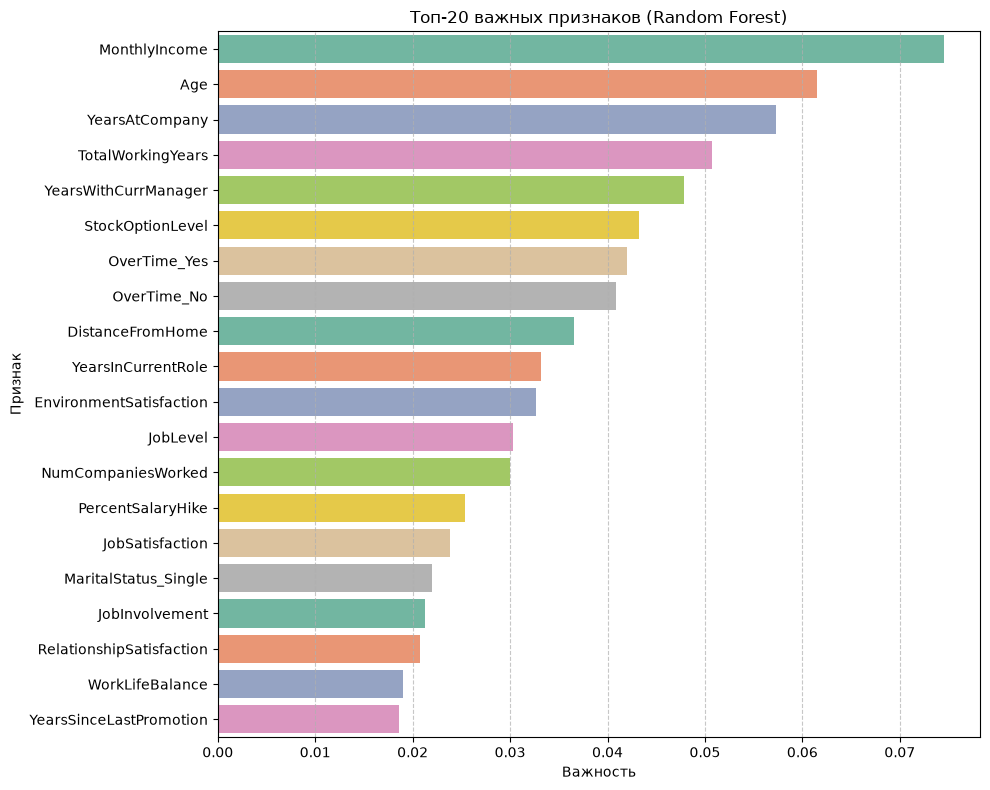


Топ-15 самых важных признаков:
MonthlyIncome              0.0745
Age                        0.0615
YearsAtCompany             0.0573
TotalWorkingYears          0.0507
YearsWithCurrManager       0.0479
StockOptionLevel           0.0432
OverTime_Yes               0.0420
OverTime_No                0.0409
DistanceFromHome           0.0366
YearsInCurrentRole         0.0332
EnvironmentSatisfaction    0.0327
JobLevel                   0.0303
NumCompaniesWorked         0.0300
PercentSalaryHike          0.0254
JobSatisfaction            0.0238
dtype: float64


In [107]:
model = best_pipeline.named_steps['model']

if hasattr(model, 'feature_importances_'):
    importances = pd.Series(
        model.feature_importances_,
        index=all_feature_names
    ).sort_values(ascending=False)

    importances.index = (
        importances.index
        .str.replace('num__', '', regex=False)
        .str.replace('cat__', '', regex=False)
    )

    plt.figure(figsize=(10, 8))
    sns.barplot(x=importances.head(20).values, y=importances.head(20).index, palette='Set2')
    plt.title('Топ-20 важных признаков (Random Forest)')
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    

    
    print("\nТоп-15 самых важных признаков:")
    print(importances.head(15).round(4))
    
